## Mathematical Foundations of Computer Graphics and Vision 2023
## Exercise 2 - Global Optimization

In this exercise you will apply what you learned about global optimization, especially branch and bound (B&B), concave and convex envelopes, and reformulation. You will implement branch and bound for consensus set maximization.

<b style="color:red"> TODO A: </b>:  Derivation of the problem formulation in the canonical form of Linear Programming. Please explain all your steps clearly. You may use the hints and notation from section 2 of the excercise sheet.

Dear TA, I am pretty new to writing formulas in markdown. The compilation works correctly when I use google colab. But in case it raises problem when you read it, I made screenshots in the folder "derivation" (from d1 to d5). Please look at them if you met any problem with the markdown here.

#### original problem
#### $$\max_{\Theta, S_I}\text{card}(\mathcal{S}_I)$$ where $$\Theta=(T_x, T_y)$$ s.t. $$|x_i+T_x-x'_i|\leq \delta, ∀i \in S_I ⊆ S$$ $$|y_i+T_y-y'_i|\leq \delta, ∀i \in S_I ⊆ S$$
<br/>

#### 1. We first introduce the identification binary variable $z_i$ with $i=1...n$. Let $z_i=1$ if the i-th correspondence is an inlier and $z_i=0$ otherwise.This step leads us to the following formula:

#### $$\max_{\textbf{z}, \Theta} \sum_{i=1}^n z_i$$ s.t. $$z_i|x_i+T_x-x'_i|\leq z_i\delta, ∀i = 1...n$$ $$z_i|y_i+T_y-y'_i|\leq z_i\delta, ∀i = 1...n$$ and

#### $$z_i \in \{0,1\}, ∀i = 1...n$$ and $$\underline{T_x} \leq T_x \leq \overline{T_x}$$ $$\underline{T_y} \leq T_y \leq \overline{T_y}$$
<br/>

#### 2. We relax the binary variables $z_i$. Which means instead of: $$z_i \in \{0,1\}, ∀i = 1...n$$ we now have: $$z_i \in [0,1], ∀i = 1...n$$

#### 3. To aviod bilinear terms, we introduce the auxiliary variables $w_{ix} = z_iT_x$ and $w_{iy} = z_iT_y$.

#### Bring $z_i$ from the outside of the absolute value to the inside, now we have $$|z_ix_i+z_iT_x-z_ix'_i|\leq z_i\delta, ∀i = 1...n$$ $$|z_iy_i+z_iT_y-z_iy'_i|\leq z_i\delta, ∀i = 1...n$$

#### Now use the auxiliary variables we get: $$\max_{\textbf{z}, \Theta, w_x, w_y} \sum_{i=1}^n z_i$$ $$|z_ix_i+w_{ix}-z_ix'_i|\leq z_i\delta, ∀i = 1...n$$ $$|z_iy_i+w_{iy}-z_iy'_i|\leq z_i\delta, ∀i = 1...n$$ where $w_x$ represent all $w_{ix}$, same for $w_y$.

<br/>

#### 4. Now let's introduce the concave and convex envelopes for the auxiliary variables. $$ conv(z_i, T_x) \leq w_{ix} \leq conc(z_i, T_x)$$  $$ conv(z_i, T_y) \leq w_{iy} \leq conc(z_i, T_y)$$ $$∀i = 1...n$$

#### Using the formula given in the class, and use $α=z_i$ and $β = T_x$ we get $[\underline{α}, \overline{\alpha}] = [0,1]$ and $[\underline{\beta}, \overline{\beta}] = [\underline{T_x}, \overline{T_x}]$. So we get: $$w_{ix} \geq \underline{T_x}z_i$$ $$w_{ix} \geq {T_x}+\overline{T_x}z_i-\overline{T_x}$$
$$w_{ix} \leq {T_x}+\underline{T_x}z_i-\underline{T_x}$$ $$w_{ix} \leq \overline{T_x}z_i$$

#### We do the same for $T_y$ and get $$w_{iy} \geq \underline{T_y}z_i$$ $$w_{iy} \geq {T_y}+\overline{T_y}z_i-\overline{T_y}$$
$$w_{iy} \leq {T_y}+\underline{T_y}z_i-\underline{T_y}$$ $$w_{iy} \leq \overline{T_y}z_i$$

<br/>

#### 5. Now we reformulate the constraints containing absolute terms, i.e. |a| ≤ b ⇒ a ≤ b and −a ≤ b. The terms in the end of step 3 now becomes:
$$z_ix_i+w_{ix}-z_ix'_i \leq z_i\delta, ∀i = 1...n$$
$$-z_ix_i-w_{ix}+z_ix'_i \leq z_i\delta, ∀i = 1...n$$
$$z_iy_i+w_{iy}-z_iy'_i \leq z_i\delta, ∀i = 1...n$$
$$-z_iy_i-w_{iy}-z_iy'_i \leq z_i\delta, ∀i = 1...n$$

<br/>

#### 6. Now summarize what we already have and write them together:
$$\max_{\textbf{z}, \Theta, w_x, w_y} \sum_{i=1}^n z_i$$ s.t.
$$z_ix_i+w_{ix}-z_ix'_i \leq z_i\delta, ∀i = 1...n$$
$$-z_ix_i-w_{ix}+z_ix'_i \leq z_i\delta, ∀i = 1...n$$
$$z_iy_i+w_{iy}-z_iy'_i \leq z_i\delta, ∀i = 1...n$$
$$-z_iy_i-w_{iy}-z_iy'_i \leq z_i\delta, ∀i = 1...n$$ and

$$w_{ix} \geq \underline{T_x}z_i$$
$$w_{ix} \geq {T_x}+\overline{T_x}z_i-\overline{T_x}$$
$$w_{ix} \leq {T_x}+\underline{T_x}z_i-\underline{T_x}$$
$$w_{ix} \leq \overline{T_x}z_i$$
$$∀i = 1...n$$ and

$$w_{iy} \geq \underline{T_y}z_i$$
$$w_{iy} \geq {T_y}+\overline{T_y}z_i-\overline{T_y}$$
$$w_{iy} \leq {T_y}+\underline{T_y}z_i-\underline{T_y}$$
$$w_{iy} \leq \overline{T_y}z_i$$
$$∀i = 1...n$$ and

$$0 \leq z_i \leq 1, ∀i = 1...n$$ and

$$\underline{T_x} \leq T_x \leq \overline{T_x}$$
$$\underline{T_y} \leq T_y \leq \overline{T_y}$$ and

$$-\infty \leq w_{ix} \leq \infty$$
$$-\infty \leq w_{iy} \leq \infty$$

and $$z_i \in \mathbb{R}, T_x \in \mathbb{R}, T_y \in \mathbb{R}, w_{ix} \in \mathbb{R}, w_{iy} \in \mathbb{R}, ∀i = 1...n.$$

#### 7. reformulate the conditions to build the canonical form:
$$\min_{\textbf{z}, \Theta, w_x, w_y} -\sum_{i=1}^n z_i$$ s.t.
$$(x_i-x'_i-\delta)z_i+w_{ix} \leq 0, ∀i = 1...n$$
$$(-x_i+x'_i-\delta)z_i-w_{ix} \leq 0, ∀i = 1...n$$
$$(y_i-y'_i-\delta)z_i+w_{iy} \leq 0, ∀i = 1...n$$
$$(-y_i+y'_i-\delta)z_i-w_{iy} \leq 0, ∀i = 1...n$$ and

$$\underline{T_x}z_i - w_{ix} \leq 0$$
$${T_x}+\overline{T_x}z_i-w_{ix} \leq \overline{T_x}$$
$$-{T_x}-\underline{T_x}z_i + w_{ix} \leq -\underline{T_x}$$
$$-\overline{T_x}z_i + w_{ix} \leq 0$$
$$∀i = 1...n$$ and

$$\underline{T_y}z_i - w_{iy} \leq 0$$
$${T_y}+\overline{T_y}z_i-w_{iy} \leq \overline{T_y}$$
$$-{T_y}-\underline{T_y}z_i + w_{iy} \leq -\underline{T_y}$$
$$-\overline{T_y}z_i + w_{iy} \leq 0$$
$$∀i = 1...n$$ and

$$0 \leq z_i \leq 1, ∀i = 1...n$$ and

$$\underline{T_x} \leq T_x \leq \overline{T_x}$$
$$\underline{T_y} \leq T_y \leq \overline{T_y}$$ and

$$-\infty \leq w_{ix} \leq \infty$$
$$-\infty \leq w_{iy} \leq \infty$$

and $$z_i \in \mathbb{R}, T_x \in \mathbb{R}, T_y \in \mathbb{R}, w_{ix} \in \mathbb{R}, w_{iy} \in \mathbb{R}, ∀i = 1...n.$$

<br/>

#### To fully write out the formulas require a lot of time and space, e.g.
$$(x_i-x'_i-\delta)z_i+w_{ix} \leq 0, ∀i = 1...n$$ can be written as
$$0*T_x + 0*T_y + (x_1-x'_1-\delta)z_1+ 0*z_2 + ... +0*z_n + 1*w_{1x} + 0*w_{2x} +...+0*w_{nx} + 0*w_{1y}+...+0*w_{ny} \leq 0$$ then for i=2
$$0*T_x + 0*T_y + 0*z_1 + (x_2-x'_2-\delta)z_2 + ... +0*z_n + 0*w_{1x} + 1*w_{2x} +...+0*w_{nx} + 0*w_{1y}+...+0*w_{ny} \leq 0$$
$$....$$

#### So I will write the canonical form in a more compact way as above. To see how they are transformed into the form usable for scipy.optimize.linprog, see solve_relaxed_LP() method in the following code.




#### Branch and Bound Implementation for the Consensus Set Maximization Problem

<b style="color:red"> TODO B: </b>In the following code you are supposed to implement consensus set maximization by branch and bound in the context of stereo matching where the model is a 2D translation between two input images. Please use the imports listed in the cell down. You may also add more imports for example for visualization purposes if you find them useful.


In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [82]:
%matplotlib inline
import math
import heapq
from typing import Tuple, List, Optional
from collections import namedtuple
import os

import numpy as np
from scipy.io import loadmat
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# Translation Theta
T = namedtuple("T", ["x", "y"])

We provide you some skeleton code that you are free to use as it is or where you can also add/ delete parameters.
You may also write auxiliary functions if you feel the need to do so.

In [83]:
# Load input points, input image and fix delta parameter
corr = loadmat('data/ListInputPoints')['ListInputPoints'] # correspondences (nx4 array) [x_i,y_i,x_i',y_i']
N = corr.shape[0]  # number of total points

left_image = plt.imread('data/InputLeftImage.png')
right_image = plt.imread('data/InputRightImage.png')
image_size = left_image.shape

delta = 3  # inlier threshold [pixels]

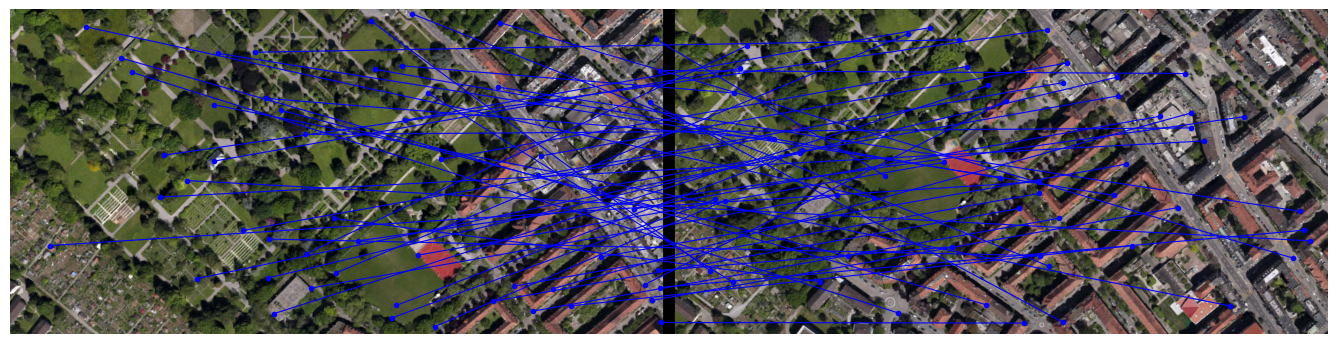

In [84]:
def plot_matches(inliers: List, outliers: List):
    fig, ax = plt.subplots(1, figsize=(17, 7))

    gap = np.zeros_like(left_image[:, :20])
    stitched = np.concatenate((left_image, gap, right_image), 1)
    ax.imshow(stitched)

    offset = left_image.shape[1] + gap.shape[1]

    for idx, line in enumerate(corr):
        x1, y1, x2, y2 = line
        if idx in inliers:
            color = "lime"
        elif idx in outliers:
            color = "crimson"
        else:
            color = "blue"

        ax.plot([x1, offset + x2], [y1, y2], ".-", color=color, linewidth=0.8)

    ax.axis('off')
    plt.show(fig)
    plt.close(fig)


plot_matches(inliers=[], outliers=[])

To help with implementing and debugging BnB, we provide a naive estimation of the inlier upper bound within box constraints of $[\underline{T_x}, \overline{T_x}]\times[\underline{T_y}, \overline{T_y}]$.

In [85]:
def naive_upper_bound(theta_lower: T, theta_upper: T) -> Tuple[T, int]:
    """
    Naive estimation of the upper bound on objective
    Calculates number of inliers in region [Tx_lb, Tx_ub]x[Ty_lb, Ty_ub]

    Parameters:
    - theta_lower, theta_upper: Lower and upper bounds for T

    Returns:
    - Tuple (translation, objcost) representing the estimated upper bound on the model and the objective
    """

    x1, y1, x2, y2 = corr.T

    T_x = x2 - x1
    T_y = y2 - y1

    inliers = (((T_x + delta) >= theta_lower.x) *
               ((T_y + delta) >= theta_lower.y) *
               ((T_x - delta) <= theta_upper.x) *
               ((T_y - delta) <= theta_upper.y))

    #Set center of region as new model
    theta = T(0.5 * (theta_lower.x + theta_upper.x), 0.5 * (theta_lower.y + theta_upper.y))

    return theta, np.sum(inliers)


In [86]:
def solve_relaxed_LP(theta_lower: T, theta_upper: T) -> Tuple[T, int]:
    """
    Parameters:
    - theta_lower, theta_upper: Lower and upper bounds for T

    Returns:
    -  Tuple that contains the solution (T, objcost) of the relaxed LP
    """

    #TODO: Implement relaxed LP
    theta = T(0, 0)
    num_inliers = 0

    x1, y1, x2, y2 = corr.T

    # let's create an array x for all variables
    # x = [T_x, T_y, z1,...,zn, w_1x,...,w_nx, w_1y,...,w_ny]
    # we have in total 2+3*N variables
    # according to the objective function, only the coefficients of z are -1, rest has zero.
    c = np.zeros((3*N+2,))
    c[2:2+N] = -1

    # (x_i-x'_i-delta)z_i+w_ix<=0
    TxTyZero = np.zeros((N,2))
    z_icoeff0 = np.diag(x1-x2-delta)
    w_ixcoeff0 = np.eye(N)
    w_iycoeff0 = np.zeros((N,N))
    A_ub0 = np.hstack((TxTyZero, z_icoeff0))
    A_ub0 = np.hstack((A_ub0, w_ixcoeff0))
    A_ub0 = np.hstack((A_ub0, w_iycoeff0))

    # (-x_i+x'_i-delta)z_i-w_ix<=0
    z_icoeff1 = np.diag(-x1+x2-delta)
    w_ixcoeff1 = np.diag(-np.ones(N))
    w_iycoeff1 = np.zeros((N,N))
    A_ub1 = np.hstack((TxTyZero, z_icoeff1))
    A_ub1 = np.hstack((A_ub1, w_ixcoeff1))
    A_ub1 = np.hstack((A_ub1, w_iycoeff1))

    # (y_i-y'_i-delta)z_i+w_iy<=0
    z_icoeff2 = np.diag(y1-y2-delta)
    w_ixcoeff2 = np.zeros((N,N))
    w_iycoeff2 = np.eye(N)
    A_ub2 = np.hstack((TxTyZero, z_icoeff2))
    A_ub2 = np.hstack((A_ub2, w_ixcoeff2))
    A_ub2 = np.hstack((A_ub2, w_iycoeff2))

    # (-y_i+y'_i-delta)z_i-w_iy<=0
    z_icoeff3 = np.diag(-y1+y2-delta)
    w_ixcoeff3 = np.zeros((N,N))
    w_iycoeff3 = np.diag(-np.ones(N))
    A_ub3 = np.hstack((TxTyZero, z_icoeff3))
    A_ub3 = np.hstack((A_ub3, w_ixcoeff3))
    A_ub3 = np.hstack((A_ub3, w_iycoeff3))

    # \underline{T_x}z_i-w_ix<=0
    z_icoeff4 = np.diag(theta_lower.x*np.ones(N))
    w_ixcoeff4 = np.diag(-np.ones(N))
    w_iycoeff4 = np.zeros((N,N))
    A_ub4 = np.hstack((TxTyZero, z_icoeff4))
    A_ub4 = np.hstack((A_ub4, w_ixcoeff4))
    A_ub4 = np.hstack((A_ub4, w_iycoeff4))

    # Tx + \overline{T_x}z_i - w_ix <= \overline{T_x}
    z_icoeff5 = np.diag(theta_upper.x*np.ones(N))
    w_ixcoeff5 = np.diag(-np.ones(N))
    w_iycoeff5 = np.zeros((N,N))
    A_ub5 = np.ones((N, 1)) # for Tx
    A_ub5 = np.hstack((A_ub5, np.zeros((N,1))))
    A_ub5 = np.hstack((A_ub5, z_icoeff5))
    A_ub5 = np.hstack((A_ub5, w_ixcoeff5))
    A_ub5 = np.hstack((A_ub5, w_iycoeff5))

    # -Tx - \underline{T_x}z_i + w_ix <= \underline{-T_x}
    z_icoeff6 = np.diag(-theta_lower.x*np.ones(N))
    w_ixcoeff6 = np.eye(N)
    w_iycoeff6 = np.zeros((N,N))
    A_ub6 = -np.ones((N, 1)) # for Tx
    A_ub6 = np.hstack((A_ub6, np.zeros((N,1))))
    A_ub6 = np.hstack((A_ub6, z_icoeff6))
    A_ub6 = np.hstack((A_ub6, w_ixcoeff6))
    A_ub6 = np.hstack((A_ub6, w_iycoeff6))

    # -\overline{T_x}z_i+w_ix<=0
    z_icoeff7 = np.diag(-theta_upper.x*np.ones(N))
    w_ixcoeff7 = np.eye(N)
    w_iycoeff7 = np.zeros((N,N))
    A_ub7 = np.hstack((TxTyZero, z_icoeff7))
    A_ub7 = np.hstack((A_ub7, w_ixcoeff7))
    A_ub7 = np.hstack((A_ub7, w_iycoeff7))


    # \underline{T_y}z_i-w_iy<=0
    z_icoeff8 = np.diag(theta_lower.y*np.ones(N))
    w_ixcoeff8 = np.zeros((N,N))
    w_iycoeff8 = np.diag(-np.ones(N))
    A_ub8 = np.hstack((TxTyZero, z_icoeff8))
    A_ub8 = np.hstack((A_ub8, w_ixcoeff8))
    A_ub8 = np.hstack((A_ub8, w_iycoeff8))

    # Ty + \overline{T_y}z_i - w_iy <= \overline{T_y}
    z_icoeff9 = np.diag(theta_upper.y*np.ones(N))
    w_ixcoeff9 = np.zeros((N,N))
    w_iycoeff9 = np.diag(-np.ones(N))
    A_ub9 = np.zeros((N, 1)) # for Tx
    A_ub9 = np.hstack((A_ub9, np.ones((N,1))))
    A_ub9 = np.hstack((A_ub9, z_icoeff9))
    A_ub9 = np.hstack((A_ub9, w_ixcoeff9))
    A_ub9 = np.hstack((A_ub9, w_iycoeff9))

    # -Ty - \underline{T_y}z_i + w_iy <= \underline{-T_y}
    z_icoeff10 = np.diag(-theta_lower.y*np.ones(N))
    w_ixcoeff10 = np.zeros((N,N))
    w_iycoeff10 = np.eye(N)
    A_ub10 = np.zeros((N,1)) # for Tx
    A_ub10 = np.hstack((A_ub10, -np.ones((N, 1))))
    A_ub10 = np.hstack((A_ub10, z_icoeff10))
    A_ub10 = np.hstack((A_ub10, w_ixcoeff10))
    A_ub10 = np.hstack((A_ub10, w_iycoeff10))

    # -\overline{T_y}z_i+w_iy<=0
    z_icoeff11 = np.diag(-theta_upper.y*np.ones(N))
    w_ixcoeff11 = np.zeros((N,N))
    w_iycoeff11 = np.eye(N)
    A_ub11 = np.hstack((TxTyZero, z_icoeff11))
    A_ub11 = np.hstack((A_ub11, w_ixcoeff11))
    A_ub11 = np.hstack((A_ub11, w_iycoeff11))

    # stack all A_ub
    A_ub = A_ub0
    A_ub = np.vstack((A_ub, A_ub1))
    A_ub = np.vstack((A_ub, A_ub2))
    A_ub = np.vstack((A_ub, A_ub3))
    A_ub = np.vstack((A_ub, A_ub4))
    A_ub = np.vstack((A_ub, A_ub5))
    A_ub = np.vstack((A_ub, A_ub6))
    A_ub = np.vstack((A_ub, A_ub7))
    A_ub = np.vstack((A_ub, A_ub8))
    A_ub = np.vstack((A_ub, A_ub9))
    A_ub = np.vstack((A_ub, A_ub10))
    A_ub = np.vstack((A_ub, A_ub11))

    # build b
    b_ub = np.zeros((12*N,))
    b_ub[5*N:6*N] = theta_upper.x
    b_ub[6*N:7*N] = -theta_lower.x
    b_ub[9*N:10*N] = theta_upper.y
    b_ub[10*N:11*N] = -theta_lower.y

    # build bounds
    bounds = [(theta_lower.x, theta_upper.x)]
    bounds += [(theta_lower.y, theta_upper.y)]
    bounds += [(0,1)]*N
    bounds += [(None, None)]*2*N

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds)

    Tx, Ty = res.x[:2]
    theta = T(Tx, Ty)
    num_inliers = math.floor(-res.fun)

    return theta, num_inliers


In [87]:
def is_inlier(theta: T) -> np.ndarray:
    """
    Parameters:
    - theta - model that's being tested

    Returns:
    - bool vector f size N, where i-th element indicates if i-th point of `corr` is an inlier
    """

    #TODO: Compute if i-th element is an inliers
    x1, y1, x2, y2 = corr.T

    cost_x = np.abs(x1 - x2 + theta.x)
    cost_y = np.abs(y1 - y2 + theta.y)
    is_inlier_x = cost_x<=delta
    is_inlier_y = cost_y<=delta
    inliers = is_inlier_x & is_inlier_y

    return inliers


In [88]:
class Problem:
  def __init__(self, theta_lower: T, theta_upper: T, obj_lower: int, obj_upper: int, theta_optimizer: T):
    self.theta_lower = theta_lower
    self.theta_upper = theta_upper
    self.obj_lower = obj_lower
    self.obj_upper = obj_upper
    self.theta_optimizer = theta_optimizer

  def __lt__(self, other):
    return self.obj_upper > other.obj_upper



In [89]:
def consensus_set_maximization_by_bnb(image_size: Tuple[int, int], upper_bound_fn) -> Tuple[T, List[int], List[int]]:
    """
    Parameters:
    - image_size - tuple of image size (H, W)

    Returns a tuple of
    - Best model according to the BnB algorithm
    - list of upper bounds for each iteration
    - list of lower bounds for each iteration
    """

    h, w, _ = image_size

    best_model = T(0, 0)
    upper_bounds = []
    lower_bounds = []

    #TODO: Implement BnB

    # perform the very first problem
    theta_lower = T(-1000, -1000)
    theta_upper = T(1000, 1000)
    theta_optimizer, obj_upper = upper_bound_fn(theta_lower, theta_upper)
    obj_lower = np.sum(is_inlier(theta_optimizer))

    problems = [Problem(theta_lower, theta_upper, obj_lower, obj_upper, theta_optimizer)]
    heapq.heapify(problems)
    upper_bounds.append(obj_upper)
    lower_bounds.append(obj_lower)
    best_model = theta_optimizer

    # the iterations stop when the lower and upper bound are nearer than 1 or when no more problems
    while len(list(problems))>0 and abs(upper_bounds[-1]-lower_bounds[-1])>=1:
      # take the best candidate in the list
      problem = heapq.heappop(problems)
      ctheta_lower = problem.theta_lower
      ctheta_upper = problem.theta_upper
      x_diff = ctheta_upper.x-ctheta_lower.x
      y_diff = ctheta_upper.y-ctheta_lower.y

      child0_theta_lower = T(0,0)
      child0_theta_upper = T(0,0)
      child1_theta_lower = T(0,0)
      child1_theta_upper = T(0,0)

      # when branching, split the current space into two children subspaces in half along the longest dimension
      if x_diff >= y_diff:
        child0_theta_lower = T(ctheta_lower.x, ctheta_lower.y)
        child0_theta_upper = T(ctheta_lower.x+x_diff/2, ctheta_upper.y)
        child1_theta_lower = T(ctheta_lower.x+x_diff/2, ctheta_lower.y)
        child1_theta_upper = T(ctheta_upper.x, ctheta_upper.y)
      else:
        child0_theta_lower = T(ctheta_lower.x, ctheta_lower.y)
        child0_theta_upper = T(ctheta_upper.x, ctheta_lower.y+y_diff/2)
        child1_theta_lower = T(ctheta_lower.x, ctheta_lower.y+y_diff/2)
        child1_theta_upper = T(ctheta_upper.x, ctheta_upper.y)

      # for each child
      # compute the upper bound of the nb of inliers by solving the LP
      # compute the lower bound of the nb of inliers by simply testing the model obtained by LP
      child0_theta_optimizer, child0_obj_upper = upper_bound_fn(child0_theta_lower, child0_theta_upper)
      child0_obj_lower = np.sum(is_inlier(child0_theta_optimizer))
      child1_theta_optimizer, child1_obj_upper = upper_bound_fn(child1_theta_lower, child1_theta_upper)
      child1_obj_lower = np.sum(is_inlier(child1_theta_optimizer))

      child0_problem = Problem(child0_theta_lower, child0_theta_upper, child0_obj_lower, child0_obj_upper, child0_theta_optimizer)
      child1_problem = Problem(child1_theta_lower, child1_theta_upper, child1_obj_lower, child1_obj_upper, child1_theta_optimizer)

      # update the highest lower bound obtained so far
      lower_bounds.append(lower_bounds[-1])
      if child0_obj_lower > lower_bounds[-1]:
        lower_bounds[-1] = child0_obj_lower
        best_model = child0_theta_optimizer

      if child1_obj_lower > lower_bounds[-1]:
        lower_bounds[-1] = child1_obj_lower
        best_model = child1_theta_optimizer

      # add the children to the heap
      heapq.heappush(problems, child0_problem)
      heapq.heappush(problems, child1_problem)

      # update the highest upper bound still in the list
      first_in_heap = heapq.heappop(problems)
      upper_bounds.append(first_in_heap.obj_upper)
      heapq.heappush(problems, first_in_heap)

      # iterate and remove the spaces that definitely do not contain the optimal solution
      for p in list(problems):
        if p.obj_upper < lower_bounds[-1]:
          list(problems).remove(p)

    return best_model, lower_bounds, upper_bounds


In [90]:
def plot_bound_convergence(lower_bounds: List[int], upper_bounds: List[int]):
    fig, ax = plt.subplots(1, figsize=(17, 7))

    iterations = np.arange(len(lower_bounds)) + 1

    # Draw lines
    ax.plot(iterations, lower_bounds, marker="o", color="r")
    ax.plot(iterations, upper_bounds, marker="o", color="b")

    # Write titles
    ax.set_title("Convergence of Bounds")
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Upper and Lower Bounds")
    ax.legend(["Lower Bound", "Upper Bound"], loc="upper right")
    ax.xaxis.set_major_locator(MultipleLocator(1 if len(lower_bounds) < 20 else 5))
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.grid(True)

    plt.show(fig)
    plt.close(fig)


In [91]:
def perform_bnb(upper_bound_fn):

    #perform consensus set maximization
    best_model, lower_bounds, upper_bounds = consensus_set_maximization_by_bnb(image_size, upper_bound_fn)

    inliers = is_inlier(best_model)

    inliers_indices = np.where(inliers)[0]
    outliers_indices = np.where(~inliers)[0]

    print(f"Global optimal translational model (Tx, Ty) = {best_model}")
    print(f"Inlier set S_I: {inliers_indices} ({len(inliers_indices)} points)")
    print(f"Outlier indices S_O = S\S_I: {outliers_indices}")

    plot_matches(inliers_indices, outliers_indices)

    plot_bound_convergence(lower_bounds, upper_bounds)


#### Results

<b style="color:red"> TODO C-E: </b> Present and discuss your results. Also plot the figures described in the deliverables D and E.

Global optimal translational model (Tx, Ty) = T(x=-234.375, y=-156.25)
Inlier set S_I: [ 2  7  8 14 15 19 25 30 31 33 34 39 41 44 50] (15 points)
Outlier indices S_O = S\S_I: [ 0  1  3  4  5  6  9 10 11 12 13 16 17 18 20 21 22 23 24 26 27 28 29 32
 35 36 37 38 40 42 43 45 46 47 48 49 51 52 53 54]


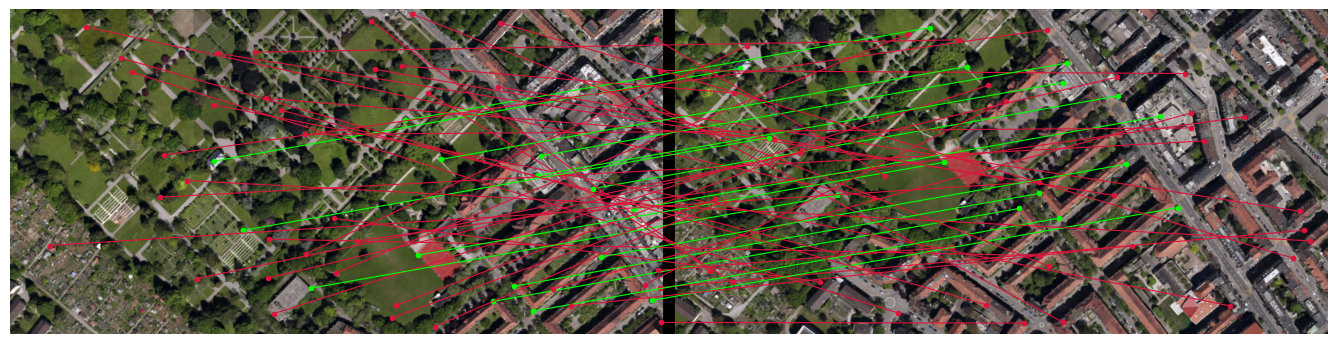

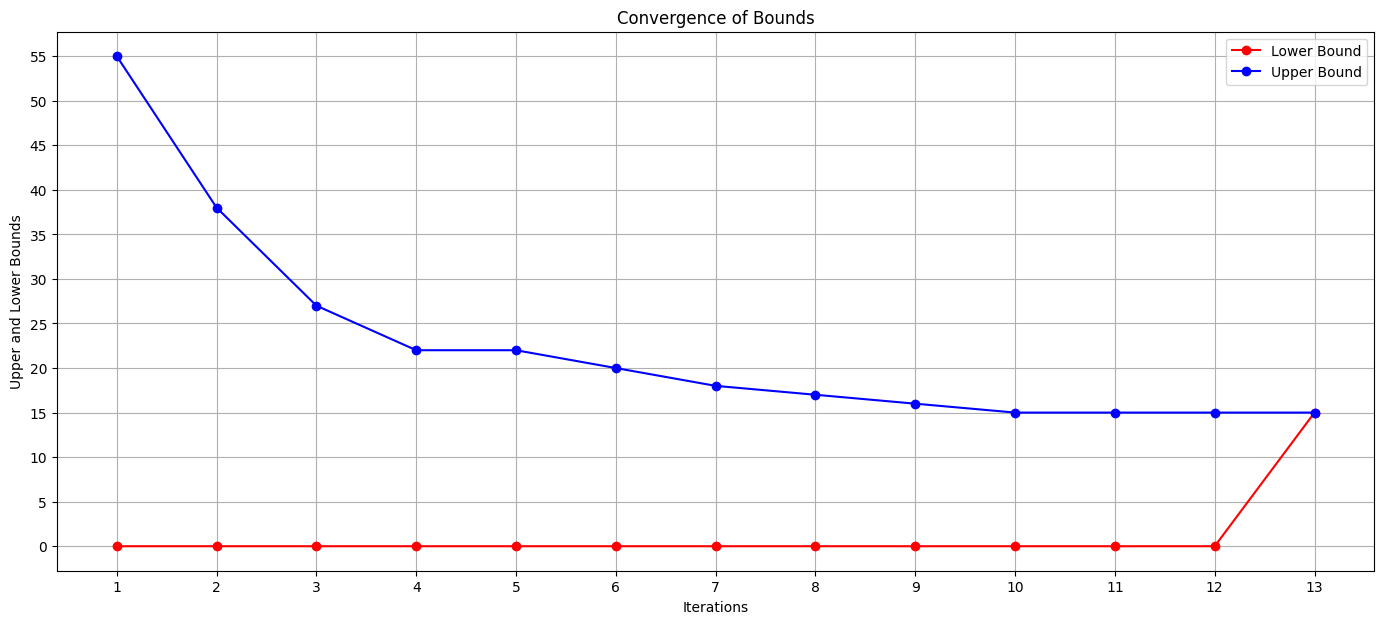

In [92]:
# Display results with the naive upper bound
perform_bnb(naive_upper_bound)

Global optimal translational model (Tx, Ty) = T(x=-232.0, y=-160.0)
Inlier set S_I: [ 2  7  8 14 15 19 25 30 31 33 34 39 41 44 50] (15 points)
Outlier indices S_O = S\S_I: [ 0  1  3  4  5  6  9 10 11 12 13 16 17 18 20 21 22 23 24 26 27 28 29 32
 35 36 37 38 40 42 43 45 46 47 48 49 51 52 53 54]


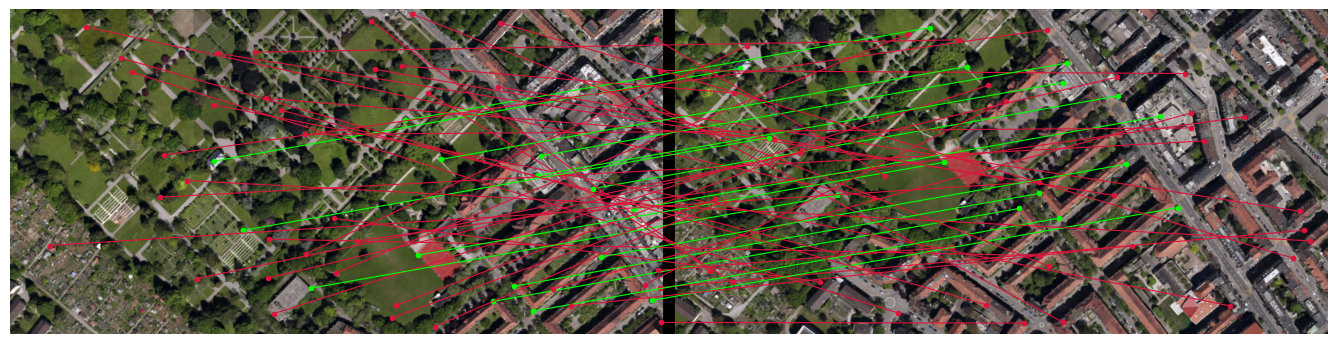

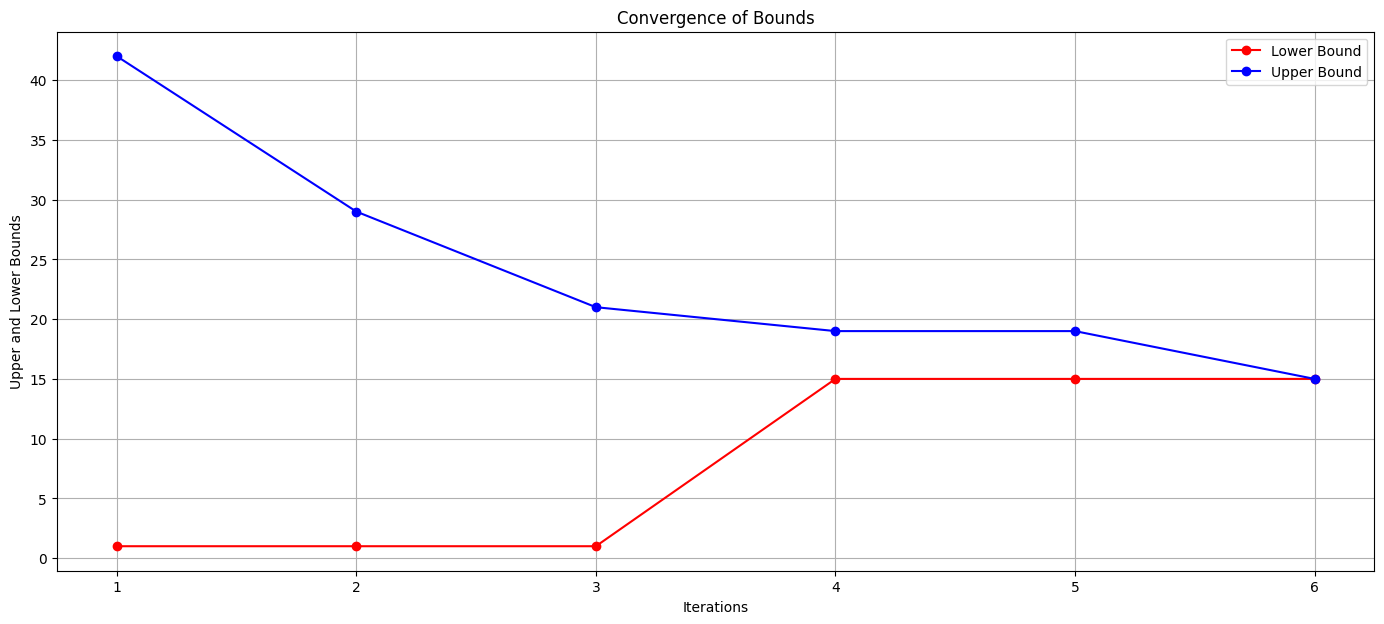

In [93]:
# Display results with the LP upper bound
perform_bnb(solve_relaxed_LP)

<b style="color:red"> Discussion (not graded): </b> In the previous exercise, you implemented RANSAC to fit polynomials. Now, can you use RANSAC to solve the consensus set maximization problem for stereo matching? If so, please briefly describe the main steps you would take to implement RANSAC for this task, and compare it with the BnB approach. Additionally, can you identify scenarios where one approach may be more effective than the other? If not, explain why it is not feasible to adapt RANSAC for this application. Can you also combine RANSAC and BnB in one pipeline?

_TODO_: Your answer here